正在读取软件包列表...
Failed to install Times New Roman font: Command 'apt-get update && apt-get install -y ttf-mscorefonts-installer fontconfig && fc-cache -f -v' returned non-zero exit status 100.
Using font: DejaVu Serif


E: 无法打开锁文件 /var/lib/apt/lists/lock - open (13: 权限不够)
E: 无法对目录 /var/lib/apt/lists/ 加锁
W: 用 unlink 删除文件 /var/cache/apt/pkgcache.bin 出错 - RemoveCaches (13: 权限不够)
W: 用 unlink 删除文件 /var/cache/apt/srcpkgcache.bin 出错 - RemoveCaches (13: 权限不够)
/home/aizoo/miniconda3/envs/mb/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/aizoo/miniconda3/envs/mb/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


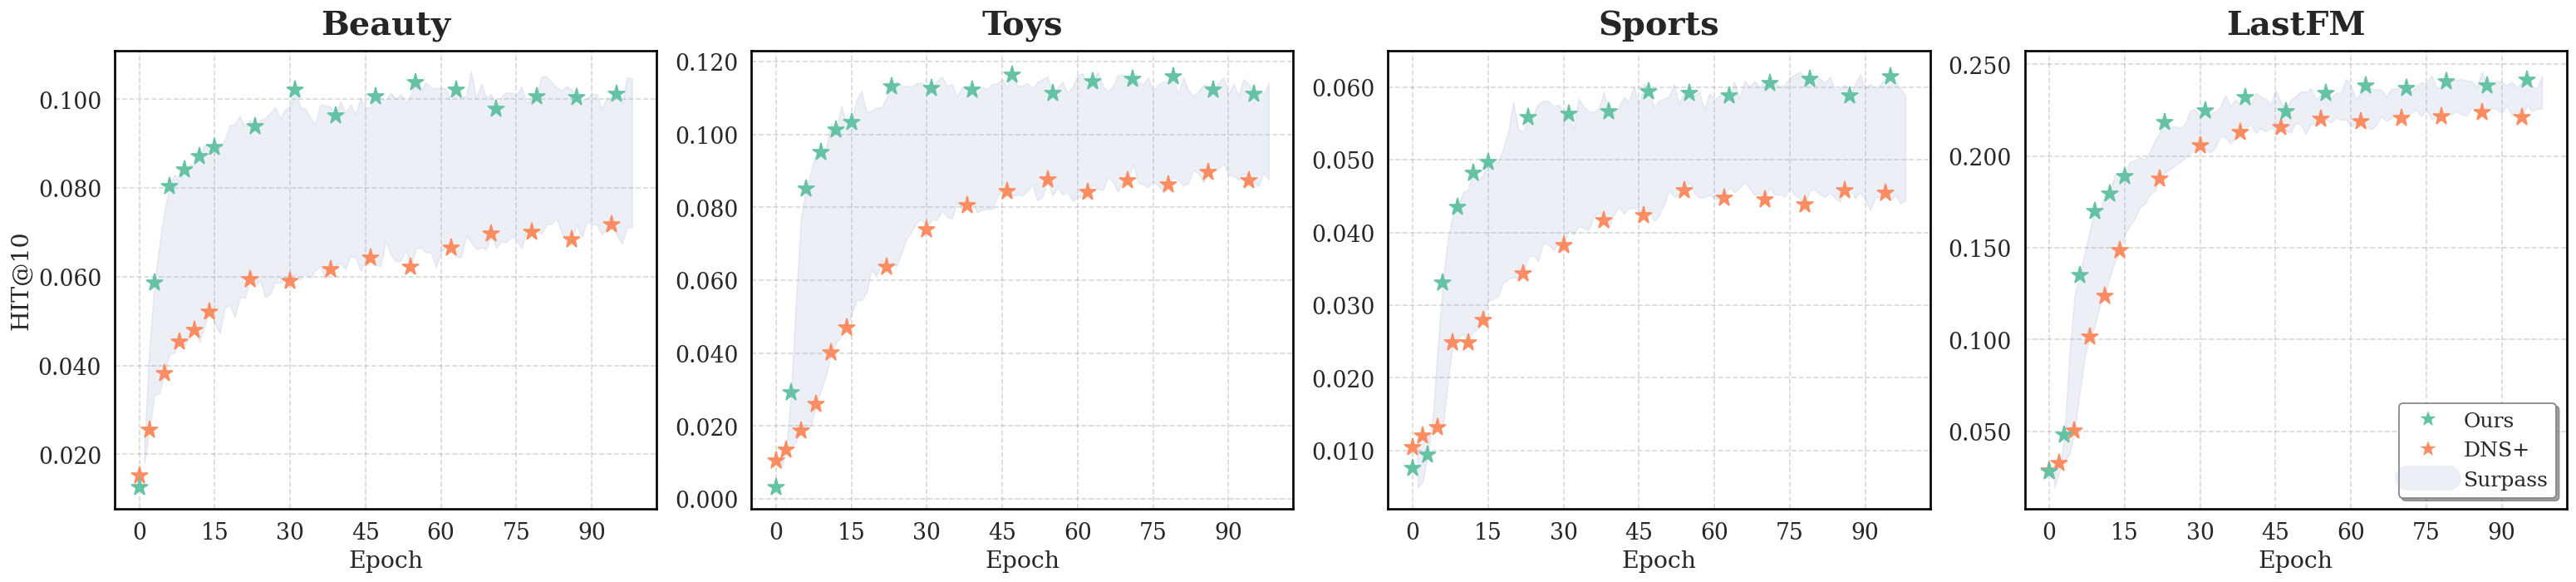

In [33]:
import sys
import subprocess

def install_ttf_fonts():
    try:
        # For Linux - install Microsoft fonts (including Times New Roman)
        if sys.platform.startswith("linux"):
            subprocess.check_call(
                "apt-get update && apt-get install -y ttf-mscorefonts-installer fontconfig && fc-cache -f -v",
                shell=True,
            )
        elif sys.platform.startswith("darwin"):
            print("On macOS, Times New Roman is usually pre-installed. If not, install via Microsoft Office or font websites.")
        elif sys.platform.startswith("win"):
            # Times New Roman is always present on Windows.
            pass
    except Exception as e:
        print("Failed to install Times New Roman font:", e)

install_ttf_fonts()

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from matplotlib import rcParams
from matplotlib.lines import Line2D
import re

# 检查 Times New Roman 是否可用，否则 fallback 到 DejaVuSerif
font_candidates = ['Times New Roman', 'TimesNewRoman', 'DejaVu Serif']
available_fonts = set(f.name for f in fm.fontManager.ttflist)
font_choice = None
for f in font_candidates:
    if f in available_fonts:
        font_choice = f
        break
if font_choice is None:
    print("Warning: Times New Roman font not found! Falling back to default serif font.")
    font_choice = 'serif'
else:
    print(f"Using font: {font_choice}")

rcParams['font.family'] = font_choice
sns.set_theme(style="whitegrid", font=font_choice, rc={"font.sans-serif": [font_choice], "font.family": "serif"})

# 数据集及其简称
datasets = ["Beauty", "Toys_and_Games", "Sports", "LastFM"]
dataset_abbr = ["Beauty", "Toys", "Sports", "LastFM"]

# 日志文件路径
log_files = [
    "../TEST_KD/Beauty-SASRec-Mamba4Rec_a1.0_b1.0_l1.0_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log",
    "../TEST_KD/Toys_and_Games-SASRec-Mamba4Rec_a1.0_b1.0_l1.0_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log",
    "../TEST_KD/Sports_and_Outdoors-SASRec-Mamba4Rec_a1.0_b1.0_l3.5_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log",
    "../TEST_KD/LastFM-SASRec-Mamba4Rec_a1.0_b1.0_l1.0_dwsb1.0_t0.0_k1_N100_kdt1.0_kdg0.01.log"
]
log_files_DNS = [
    "./cankao_DNS+/Beauty-SASRec_0_N100_M10.log",
    "./cankao_DNS+/Toys_and_Games-SASRec_0_N100_M10.log",
    "./cankao_DNS+/Sports_and_Outdoors-SASRec_0_N100_M10.log",
    "./cankao_DNS+/LastFM-SASRec_m20.log"
]


palette = sns.color_palette("Set2", 3)


# 匹配 Model 1 (SASRec) Results: {...} 这种字符串并提取 HIT@10 和 Epoch
def extract_hit(log_path, ours=True):
    epochs = []
    hit10s = []
    if ours:
        pattern = re.compile(
            r"Model 1 \(SASRec\) Results:\s*\{[^}]*'Epoch':\s*(\d+)[^}]*'HIT@10':\s*'([\d.]+)'", re.I
        )
    else:
        # 匹配 {'Epoch': 3, 'HIT@5': '0.0100', ...} 这种字符串并提取 'Epoch' 和 'HIT@10'
        pattern = re.compile(
            r"\{'Epoch':\s*(\d+)[^}]*'HIT@10':\s*'([\d.]+)'", re.I
        )
        
    try:
        with open(log_path) as f:
            lines = list(f)
            matches = []
            for line in lines:
                m = pattern.search(line)
                if m:
                    epoch = int(m.group(1))
                    hit10 = float(m.group(2))
                    matches.append((epoch, hit10))
            # 跳过第偶数个和最后一个
            # (1-based) 所以第偶数个是下标1,3,5... 其实就是下标%2==1的位置, 末尾也要去掉
            if ours:
                filtered = [t for i, t in enumerate(matches) if i % 2 == 0 and i != len(matches) - 1]
            else:
                filtered = [t for i, t in enumerate(matches) if i != len(matches) - 1]                
            for epoch, hit10 in filtered:
                epochs.append(epoch)
                hit10s.append(hit10)
    except Exception as e:
        print(f"Error reading {log_path}: {e}")
    return epochs, hit10s

fig, axes = plt.subplots(1, 4, figsize=(26, 6), dpi=120, sharey=False)  # 每个图纵坐标独立

if len(np.shape(axes)) == 0:  # 只画一个时axes不是列表
    axes = [axes]

for idx, (log_file, log_file_DNS, abbr, ax) in enumerate(zip(log_files, log_files_DNS, dataset_abbr, axes)):
    # 提取我们的方法
    epochs_ours, hit10s_ours = extract_hit(log_file, ours=True)
    # 提取DNS方法
    epochs_dns, hit10s_dns = extract_hit(log_file_DNS, ours=False)

    # 检查ours是否有数据
    if not epochs_ours or not hit10s_ours:
        print(f"数据集{abbr}未能成功加载数据（ours）！")
        continue

    # ours: 按epoch排序
    ss_ours = sorted(zip(epochs_ours, hit10s_ours))
    epochs_ours, hit10s_ours = zip(*ss_ours)
    epochs_ours = list(epochs_ours)
    hit10s_ours = list(hit10s_ours)

    # ours: 只画前30个epoch
    limit = 100
    limited_n_ours = min(limit, len(epochs_ours))
    epochs_ours = epochs_ours[:limited_n_ours]
    hit10s_ours = hit10s_ours[:limited_n_ours]

    # ours: 前15个epoch每3个画星星，后面每8个epoch画一个星星
    star_indices_ours = []
    for i in range(limited_n_ours):
        if i < 15:
            if i % 3 == 0:
                star_indices_ours.append(i)
        else:
            # 注意：如果i等于15，需要额外画一个星星。因此这里i==15的时候也应该append
            # 所以后面8个，不包括15这一位的话，i从15,23,31,...起，每8个画一个
            # 但由于这里限定最多limit（比如30/100）个epoch，因此后续不会越界
            if (i - 15) % 8 == 0:
                star_indices_ours.append(i)
    star_epochs_ours = [epochs_ours[i] for i in star_indices_ours]
    star_hit10s_ours = [hit10s_ours[i] for i in star_indices_ours]

    # DNS：如有数据才画
    if epochs_dns and hit10s_dns:
        ss_dns = sorted(zip(epochs_dns, hit10s_dns))
        epochs_dns, hit10s_dns = zip(*ss_dns)
        epochs_dns = list(epochs_dns)
        hit10s_dns = list(hit10s_dns)
        limited_n_dns = min(limit, len(epochs_dns))
        epochs_dns = epochs_dns[:limited_n_dns]
        hit10s_dns = hit10s_dns[:limited_n_dns]

        # DNS星星索引规则同ours
        star_indices_dns = []
        for i in range(limited_n_dns):
            if i < 15:
                if i % 3 == 0:
                    star_indices_dns.append(i)
            else:
                if (i - 15) % 8 == 0:
                    star_indices_dns.append(i)
        star_epochs_dns = [epochs_dns[i] for i in star_indices_dns]
        star_hit10s_dns = [hit10s_dns[i] for i in star_indices_dns]

        # 对齐两个序列以便阴影
        min_len = min(len(epochs_ours), len(epochs_dns))
        # 找两个序列公共的epoch区间，用于阴影绘制（取二者overlap）
        joined_epochs = sorted(list(set(epochs_ours) & set(epochs_dns)))
        if len(joined_epochs) > 1:
            # 为了连贯，如果epoch不是严格都一一对应，采用插值处理
            # 构造插值函数
            from scipy.interpolate import interp1d
            f_dns = interp1d(epochs_dns, hit10s_dns, kind='linear', bounds_error=False, fill_value='extrapolate')
            f_ours = interp1d(epochs_ours, hit10s_ours, kind='linear', bounds_error=False, fill_value='extrapolate')
            shade_epochs = np.array(joined_epochs)
            ours_interp = f_ours(shade_epochs)
            dns_interp = f_dns(shade_epochs)
            ax.fill_between(
                shade_epochs, ours_interp, dns_interp,
                where=(ours_interp > dns_interp),
                interpolate=True, color=palette[2], alpha=0.16, zorder=1, label='Ours > DNS+'
            )
            ax.fill_between(
                shade_epochs, ours_interp, dns_interp,
                where=(dns_interp >= ours_interp),
                interpolate=True, color=palette[2], alpha=0.16, zorder=1, label='DNS+ ≥ Ours'
            )

        # # 画曲线（主线，为了阴影对比）
        # ax.plot(epochs_ours, hit10s_ours, label='Ours', color=palette[0], linewidth=2.5, zorder=3)
        # ax.plot(epochs_dns, hit10s_dns, label='DNS+', color=palette[1], linewidth=2.5, zorder=2)

        # 星标
        ax.plot(
            star_epochs_ours, star_hit10s_ours,
            marker='*', linestyle='None', color=palette[0], markersize=13, label='Ours Selected Epochs', zorder=5
        )
        ax.plot(
            star_epochs_dns, star_hit10s_dns,
            marker='*', linestyle='None', color=palette[1], markersize=13, label='DNS+ Selected Epochs', zorder=4
        )
    else:
        # 没有DNS数据仍然可以画我们的星星曲线
        ax.plot(epochs_ours, hit10s_ours, label='Ours', color=palette[0], linewidth=2.5, zorder=3)
        ax.plot(
            star_epochs_ours, star_hit10s_ours,
            marker='*', linestyle='None', color=palette[0], markersize=13, label='Ours Selected Epochs', zorder=5
        )
        print(f"数据集{abbr}未能成功加载数据（DNS）！")

    # 子图标题
    ax.set_title(f"{abbr}", fontsize=24, fontweight='bold', pad=12, family=font_choice)
    ax.set_xlabel("Epoch", fontsize=17, family=font_choice)
    if idx == 0:
        ax.set_ylabel("HIT@10", fontsize=17, family=font_choice)

    # 坐标轴刻度字体
    ax.tick_params(axis='both', which='major', labelsize=16)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontname(font_choice)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

    # grid
    ax.grid(axis='y', color='grey', alpha=0.30, linestyle='--', linewidth=1)
    ax.grid(axis='x', color='grey', alpha=0.30, linestyle='--', linewidth=1)

    # 坐标轴样式
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.6)
        ax.spines[spine].set_color('black')

    # 图例只在最后一个子图
    if idx == 3:
        elems = [
            # Line2D([0], [0], color=palette[0], linewidth=2.5, label='Ours'),
            # Line2D([0], [0], color=palette[1], linewidth=2.5, label='DNS+'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor=palette[0], markersize=15, linestyle='None', label='Ours'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor=palette[1], markersize=15, linestyle='None', label='DNS+'),
            # Line2D([0], [0], color=palette[0], alpha=.16, linewidth=18, label='Ours > DNS+', linestyle='-'),    # 仅作为legend项，不会实际画出
            Line2D([0], [0], color=palette[2], alpha=.16, linewidth=18, label='Surpass', linestyle='-'),   # 仅作为legend项
        ]
        legend = ax.legend(handles=elems, loc='lower right', fontsize=15, frameon=True, fancybox=True, shadow=True, handletextpad=0.7)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_alpha(1.0)
        legend.get_frame().set_edgecolor('grey')
        for text in legend.get_texts():
            text.set_fontname(font_choice)

plt.tight_layout()
plt.show()
